<a href="https://colab.research.google.com/github/anujthapamagar/Lecture_FEDS/blob/main/lecture3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/content')

import ffp2

import matplotlib.pyplot as plt


In [90]:
df = pd.read_csv('/content/july_2nd_week.csv')

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import RobustScaler
##from sklearn.datasets import make_blobs
from pylab import rcParams
plt.rcParams.update({'font.size': 14})

In [92]:
df["zma"] = df.zm - df.d
df["zmol"] = df.zm/df.L
df = df[df.u_star >= 0.2]
df = df[df.zmol >= -15.5]
df = df.dropna()
df = df.reset_index()

df.head()

,index,yyyy,mm,day,HH_UTC,MM,zm,d,z0,u_mean,L,sigma_v,u_star,wind_dir,date,zma,zmol
0,0,2015,7,8,0,15,70,13.4,-999,5.29407,843.062,1.621980,0.679911,224.847,2015-07-08,56.6,0.083031
1,1,2015,7,8,0,45,70,13.4,-999,5.14935,1137.760,1.270310,0.623401,227.603,2015-07-08,56.6,0.061524
2,2,2015,7,8,1,15,70,13.4,-999,5.33851,451.585,1.089680,0.507867,219.268,2015-07-08,56.6,0.155010
3,3,2015,7,8,1,45,70,13.4,-999,5.08884,313.622,0.812910,0.450874,221.224,2015-07-08,56.6,0.223199
4,4,2015,7,8,2,15,70,13.4,-999,4.58522,208.280,0.686362,0.352074,220.840,2015-07-08,56.6,0.336086


In [93]:
from tqdm import tqdm
res = []

for i in tqdm(range(len(df))):

    x_ci = ffp2.FFP(zm = df.zma[i],
                   z0 = None,
                   h = 1000.,
                   ol = df.L[i],
                   umean = df.u_mean[i],
                   sigmav = df.sigma_v[i],
                   ustar = df.u_star[i],
                   wind_dir = df.wind_dir[i],
                   nx = 1000)

    res.append(x_ci["x_ci_max"])

100%|██████████| 224/224 [00:05<00:00, 39.89it/s]


In [94]:
import matplotlib.pyplot as plt

x = np.sin(df.wind_dir.values*np.pi/180)*res
y = np.cos(df.wind_dir.values*np.pi/180)*res

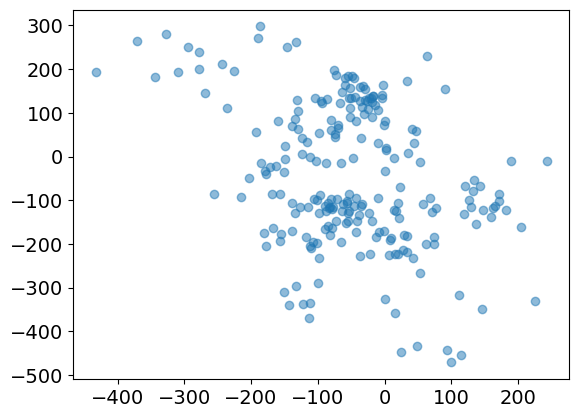

In [95]:
plt.scatter(x,y,alpha = 0.5)

In [96]:
df["x"] = pd.DataFrame(x)
df["y"] = pd.DataFrame(y)

In [97]:
df.head()

,index,yyyy,mm,day,HH_UTC,MM,zm,d,z0,u_mean,L,sigma_v,u_star,wind_dir,date,zma,zmol,x,y
0,0,2015,7,8,0,15,70,13.4,-999,5.29407,843.062,1.621980,0.679911,224.847,2015-07-08,56.6,0.083031,-114.666911,-115.280955
1,1,2015,7,8,0,45,70,13.4,-999,5.14935,1137.760,1.270310,0.623401,227.603,2015-07-08,56.6,0.061524,-127.382051,-116.303566
2,2,2015,7,8,1,15,70,13.4,-999,5.33851,451.585,1.089680,0.507867,219.268,2015-07-08,56.6,0.155010,-138.936648,-169.940972
3,3,2015,7,8,1,45,70,13.4,-999,5.08884,313.622,0.812910,0.450874,221.224,2015-07-08,56.6,0.223199,-155.321063,-177.271939
4,4,2015,7,8,2,15,70,13.4,-999,4.58522,208.280,0.686362,0.352074,220.840,2015-07-08,56.6,0.336086,-177.847751,-205.748033


In [98]:
##df.tocsv("July_2nd_week_xy.csv")

In [99]:
X = df[["x", "y"]].values

In [100]:
Xs = RobustScaler().fit_transform(X)

In [101]:
hdb = HDBSCAN(min_cluster_size=10, min_samples=10)

In [102]:
hdb.fit(Xs)
labels = hdb.fit_predict(X)

print(labels)

[ 1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  0  0
 -1  0  0 -1  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1  1 -1 -1  1  1 -1
 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1  2 -1 -1 -1  2
 -1  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2  2 -1 -1  2  2  2  2  2  2  2
  2 -1  2  2  2  2  2  2  2  2  2  2  2 -1 -1 -1 -1 -1  2  2 -1 -1  2  2
  2 -1  2 -1  2  2  2 -1 -1  2 -1  2  2  2  2  2  2  2  2 -1 -1 -1 -1  0
  1  1 -1  2  2 -1  2 -1]


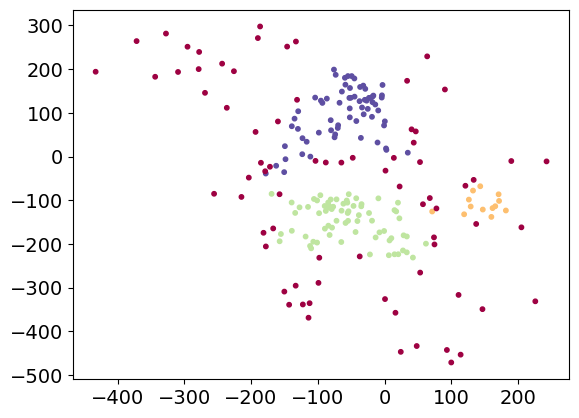

In [103]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Spectral', s=10)
plt.show()

In [104]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hdbscan_style(X, labels, probabilities=None):
    unique_labels = set(labels)

    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

    if probabilities is None:
        probabilities = np.ones(len(labels))

    for k, col in zip(unique_labels, colors):

        if k == -1:
            col = [0, 0, 0, 1]  # black for noise

        class_member_mask = (labels == k)

        # "High confidence" points (like core samples)
        high_prob = class_member_mask & (probabilities > 0.7)
        xy = X[high_prob]

        plt.plot(
            xy[:, 0],
            xy[:, 1],
            'o',
            markerfacecolor=tuple(col),
            markeredgecolor='k',
            markersize=10
        )

        # "Low confidence" points (like border points)
        low_prob = class_member_mask & (probabilities <= 0.7)
        xy = X[low_prob]

        plt.plot(
            xy[:, 0],
            xy[:, 1],
            'o',
            markerfacecolor=tuple(col),
            markeredgecolor='k',
            markersize=5
        )

    plt.title(f"Estimated number of clusters: {len(unique_labels) - (1 if -1 in labels else 0)}")
    plt.show()

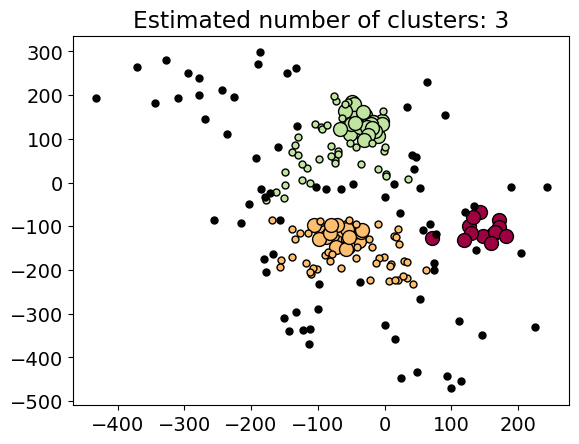

In [105]:
hdb = HDBSCAN(min_cluster_size=10, min_samples=10)
labels = hdb.fit_predict(X)

plot_hdbscan_style(X, labels, hdb.probabilities_)

In [106]:
# Add results
# df["Cluster"] = labels
# df["Probability"] = hdb.probabilities_

# # Export
# df.to_csv("hdbscan_results.csv", index=False)

In [107]:
url = "https://raw.githubusercontent.com/stenoe/timeseries-lecture/refs/heads/main/data/SMEAR_2m_daily_min_temperature.csv"
ndf = pd.read_csv(url)
ndf.head()

,date,min_temperature
0,2014-08-28,9.500000
1,2014-08-29,7.333333
2,2014-08-30,4.000000
3,2014-08-31,4.366667
4,2014-09-01,5.933333


In [108]:
import requests

# Replace with the raw URL of the Python file on GitHub
# For example, to get ffp2.py from this notebook's content:
github_raw_url = "https://raw.githubusercontent.com/StenoE/colab_tutorials/main/ffp2.py"
file_name = "ffp2_downloaded.py"

try:
    response = requests.get(github_raw_url)
    response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)

    with open(file_name, 'w') as f:
        f.write(response.text)
    print(f"Successfully downloaded '{file_name}'")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")


Error downloading the file: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/StenoE/colab_tutorials/main/ffp2.py
